In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from statsmodels.tsa.arima.model import ARIMA

In [2]:
import os
os.getcwd()

'/Users/shardul/Inverse_problems_in_QM/notebooks/agnr/time_series'

In [3]:
pristine_9 = np.load("../../../9_agnr_pris.csv.npy")
pristine_7 = np.load("../../../7_agnr_pris.csv.npy")

In [4]:
X_7 = np.load(os.path.expanduser("~/transmission_data/consolidated_data/size_7.npy"))
X_9 = np.load(os.path.expanduser("~/transmission_data/consolidated_data/size_9.npy"))

In [5]:
concs = np.arange(2, 60, 2)
indices = concs // 2 - 1


X_7_train = np.clip(X_7[indices, :10000,:150]/pristine_7[:150],0,1).reshape(-1,150)
X_9_train = np.clip(X_9[indices, :10000,:150]/pristine_9[:150],0,1).reshape(-1,150)
Y_7_predict = np.clip(X_7[indices, :10000,150:170]/pristine_7[150:170],0,1).reshape(-1,20)
Y_9_predict = np.clip(X_9[indices, :10000,150:170]/pristine_9[150:170],0,1).reshape(-1,20)


In [6]:
X_train = np.vstack([X_7_train,X_9_train])
Y_train = np.vstack([Y_7_predict,Y_9_predict])

In [7]:
df_X = pd.DataFrame(X_train,columns=[f"signal_{i}" for i in range(150)])
df_Y = pd.DataFrame(Y_train,columns=[f"signal_{i}" for i in range(20)])

In [8]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

In [8]:
random_sample = df_X.sample(frac=0.8,random_state=42).index
test_sample = df_X.index.difference(random_sample)

In [9]:
train = df_X.loc[random_sample]
target = df_Y.loc[random_sample]
test_input = df_X.loc[test_sample]
target_input = df_Y.loc[test_sample]

In [10]:
import lightgbm as lgbm
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import root_mean_squared_error

In [11]:
import os
from functools import lru_cache
import copy
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

import scipy.sparse as sp
from scipy.sparse import csr_matrix, diags
from scipy.linalg import lu_factor, lu_solve, solve
#from scipy.spatial import distance_matrix
from scipy.spatial.distance import pdist, squareform

import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset


In [54]:
class mulit_prediction(nn.Module):
    def __init__(self, input_len = 150, final_hidden_dim = 20):
        super().__init__()


        self.model = nn.Sequential(
            nn.Linear(input_len,256),
            #nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256,256),
            #nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256,128),
            #nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128,final_hidden_dim)
        )

    def forward(self,x: torch.tensor):
        return self.model(x)


In [55]:
Xtr = train.values.astype(np.float32)
Ytr = target.values.astype(np.float32)
Xte = test_input.values.astype(np.float32)
Yte = target_input.values.astype(np.float32)

train_ds = TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(Ytr))
val_ds = TensorDataset(torch.from_numpy(Xte), torch.from_numpy(Yte))
dev = "mps" if torch.backends.mps.is_available() else "cpu"
Xte_t = torch.from_numpy(Xte).to(dev)

In [44]:
xb, yb = next(iter(train_ds))
print(xb.mean())

print(yb.mean())

tensor(0.9413)
tensor(0.8704)


In [18]:
def own_loss(x, y):
    return torch.abs(x - y).sum(dim=1).mean()    # mean over spectra of ∫|ΔT| dE

In [56]:
import copy

def training_model(num_epochs):
    model = mulit_prediction(input_len=150, final_hidden_dim=20).to(dev)

    optimizer = optim.Adam(model.parameters(), lr=0.01)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=3
    )

    train_dl = DataLoader(train_ds, batch_size=1024, shuffle=True, drop_last=True)
    val_dl = DataLoader(val_ds, batch_size=512, shuffle=False)

    train_loss_his = []
    val_loss_his = []

    best_val_loss = float('inf')
    best_model_weights = None

    for epoch in range(num_epochs):
        # -----------------------
        #     TRAINING
        # -----------------------
        model.train()
        running_loss = 0.0

        for xb, yb in train_dl:
            xb = xb.to(dev)
            yb = yb.to(dev)

            optimizer.zero_grad()

            preds = model(xb)
            loss = F.mse_loss(preds, yb) #+ 0.01 * own_loss(preds, yb)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train = running_loss / len(train_dl)
        train_loss_his.append(avg_train)

        # -----------------------
        #     VALIDATION
        # -----------------------
        model.eval()
        running_val = 0.0

        with torch.no_grad():
            for xb, yb in val_dl:
                xb = xb.to(dev)
                yb = yb.to(dev)

                preds = model(xb)
                loss = F.mse_loss(preds, yb) #+ 0.01 * own_loss(preds, yb)

                running_val += loss.item()

        avg_val = running_val / len(val_dl)
        val_loss_his.append(avg_val)

        # -----------------------
        # UPDATES & CHECKPOINTING
        # -----------------------
        scheduler.step(avg_val)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_model_weights = copy.deepcopy(model.state_dict())
            print(f"Epoch {epoch+1:03d} | Train: {avg_train:.4f} | Val: {avg_val:.4f} * Saved Best")
        else:
            print(f"Epoch {epoch+1:03d} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")

    # -----------------------
    # FINALIZATION & PLOTTING
    # -----------------------
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)
        print(f"\nTraining Complete. Loaded best model with Val Loss: {best_val_loss:.4f}")

    plt.figure(figsize=(10, 6))
    plt.plot(train_loss_his, label="Train Loss")
    plt.plot(val_loss_his, label="Validation Loss")
    
    if val_loss_his:
        best_epoch_idx = val_loss_his.index(best_val_loss)
        plt.axvline(best_epoch_idx, color='green', linestyle='--', label=f'Best Model (Epoch {best_epoch_idx + 1})')

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    return model, (train_loss_his, val_loss_his)

Epoch 001 | Train: 0.0358 | Val: 0.0249 * Saved Best
Epoch 002 | Train: 0.0246 | Val: 0.0246 * Saved Best
Epoch 003 | Train: 0.0239 | Val: 0.0238 * Saved Best
Epoch 004 | Train: 0.0235 | Val: 0.0233 * Saved Best
Epoch 005 | Train: 0.0233 | Val: 0.0233 * Saved Best
Epoch 006 | Train: 0.0232 | Val: 0.0230 * Saved Best
Epoch 007 | Train: 0.0231 | Val: 0.0228 * Saved Best
Epoch 008 | Train: 0.0229 | Val: 0.0229
Epoch 009 | Train: 0.0229 | Val: 0.0229
Epoch 010 | Train: 0.0228 | Val: 0.0227 * Saved Best
Epoch 011 | Train: 0.0228 | Val: 0.0229
Epoch 012 | Train: 0.0228 | Val: 0.0231
Epoch 013 | Train: 0.0227 | Val: 0.0228
Epoch 014 | Train: 0.0227 | Val: 0.0225 * Saved Best
Epoch 015 | Train: 0.0227 | Val: 0.0227
Epoch 016 | Train: 0.0227 | Val: 0.0227
Epoch 017 | Train: 0.0227 | Val: 0.0226
Epoch 018 | Train: 0.0226 | Val: 0.0227
Epoch 019 | Train: 0.0225 | Val: 0.0225 * Saved Best
Epoch 020 | Train: 0.0225 | Val: 0.0225
Epoch 021 | Train: 0.0225 | Val: 0.0226
Epoch 022 | Train: 0.0225 | Va

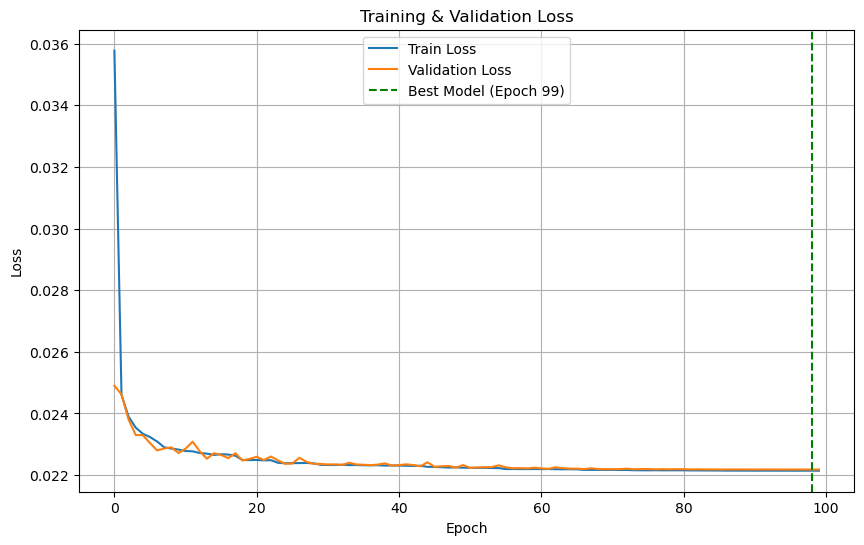

In [57]:
trained_model = training_model(100)

In [58]:
a,b = trained_model

In [40]:
batch = next(iter(train_ds))
print(type(batch))
if isinstance(batch, (list, tuple)):
    print("elements:", len(batch), [b.shape for b in batch])
else:
    print("single tensor:", batch.shape)

<class 'tuple'>
elements: 2 [torch.Size([150]), torch.Size([20])]


In [ ]:
import copy

model_bak = copy.deepcopy(a)                      # overfit test corrupts weights
opt = torch.optim.Adam(a.parameters(), lr=1e-3)   # fresh optimizer

xb, yb = next(iter(train_ds))
xb, yb = xb[:8].to(dev), yb[:8].to(dev)

a.train()
for i in range(500):
    opt.zero_grad(set_to_none=True)
    l = F.mse_loss(a(xb), yb)
    l.backward()
    opt.step()                                     # optimizer steps, not the model
    if i % 50 == 0:
        print(i, l.item())

IndexError: Dimension out of range (expected to be in range of [-1, 0], but got -2)

In [34]:
a.eval()
with torch.no_grad():
    preds = torch.cat([a(Xte_t[i:i+8192]).cpu()
                       for i in range(0, len(Xte_t), 8192)]).numpy()

mdl  = np.abs(preds - Yte)              # model error
pers = np.abs(Xte[:, -1:] - Yte)        # persistence baseline

print(f"model MAE       {mdl.mean():.4f}")
print(f"persistence MAE {pers.mean():.4f}")


model MAE       0.1039
persistence MAE 0.1636


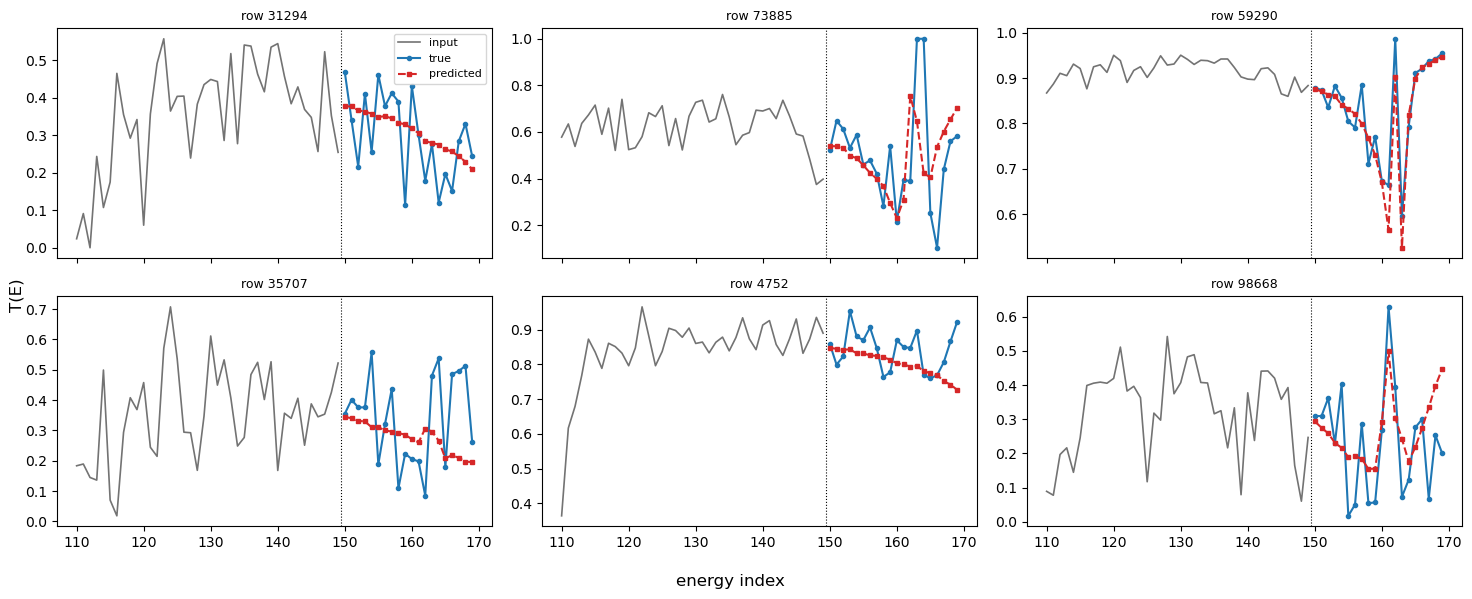

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True)
rows = np.random.default_rng(0).choice(len(Yte), 6, replace=False)

for ax, r in zip(axes.ravel(), rows):
    ax.plot(range(110, 150), Xte[r, 110:],  color="0.45", lw=1.2, label="input")
    ax.plot(range(150, 170), Yte[r],   "o-",  ms=3, color="C0", label="true")
    ax.plot(range(150, 170), preds[r], "s--", ms=3, color="C3", label="predicted")
    ax.axvline(149.5, color="k", ls=":", lw=0.8)
    ax.set_title(f"row {r}", fontsize=9)

axes[0, 0].legend(fontsize=8)
fig.supxlabel("energy index"); fig.supylabel("T(E)")
fig.tight_layout()

In [46]:
rows

array([31294, 73885, 59290, 35707,  4752, 98668])

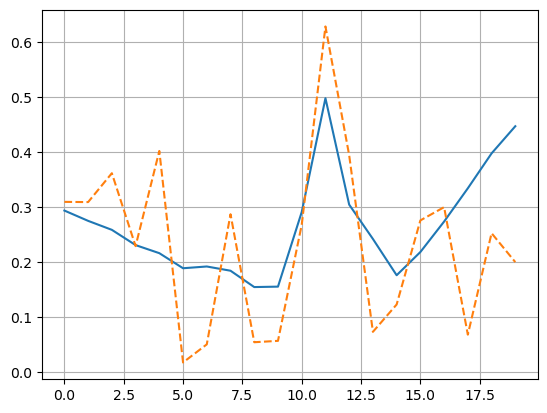

In [53]:
plt.plot(preds[rows[-1]])
plt.plot(Yte[rows[-1]], linestyle= '--')
plt.grid()